In [1]:
# ════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════

# import fsspec
# from zipfile import ZipFile
# from io import BytesIO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

URL = "gs://agntworks-data-dev/wheelsup/processed/search_activity_metro_mapping.csv"
TOP_N_CORRIDORS = 20   # corridors to show in bar chart
TOP_N_QUADRANT = 30   # corridors in abandonment quadrant
MIN_SEARCHES = 500  # min searches to include in quadrant

# Colors
C_PREMIUM  = '#2ecc71'   # green  = premium opportunity
C_SENSITIVE = '#e74c3c'  # red    = price-sensitive
C_NEUTRAL   = '#95a5a6'  # grey
CMAP_DEMAND = LinearSegmentedColormap.from_list('demand', ['#f0f3ff','#1a237e'])

In [2]:
# def load_specific_csv_from_zip(url, filename):
#     """Load one specific CSV from multi-file ZIP"""
#     with fsspec.open(url, 'rb') as f:
#         with ZipFile(BytesIO(f.read())) as z:
#             return pd.read_csv(z.open(filename))

In [3]:
df = pd.read_csv(URL, parse_dates=['createDate_et'])

# Normalise isCartAbandoned → bool
df['abandoned'] = df['isCartAbandoned'].astype(str).str.lower().eq('true')

# Unique searches (for abandonment rate — don't double-count multi-leg)
df_searches = df.drop_duplicates(subset='singleSearchRequestId')

print(f'Legs      : {len(df):,}')
print(f'Searches  : {len(df_searches):,}')
print(f'Abandoned : {df_searches["abandoned"].sum():,} ({df_searches["abandoned"].mean()*100:.1f}%)')
print(f'Date range: {df_searches["createDate_et"].min().date()} → {df_searches["createDate_et"].max().date()}')
print(f'dtype     : {df["createDate_et"].dtype}')


Legs      : 1,183,154
Searches  : 765,682
Abandoned : 104,809 (13.7%)
Date range: 2024-03-31 → 2026-04-01
dtype     : datetime64[ns]


In [18]:
df.head(10)

,singleSearchRequestId,clientUserId,memberId,createDate,isCartAbandoned,requestingApp,route,from_airport,to_airport,from_metro,to_metro,createDate_utc,createDate_et,date_et,hour_et,dow_et,abandoned
0,7154439,946808,194306.0,2025-03-30T00:31:25.000Z,False,WU-Members iOS App,KMBO-KSAT-KMBO,KMBO,KSAT,Nashville,San Antonio,2025-03-30 00:31:25+00:00,2025-03-29 20:31:25,2025-03-29,20,Saturday,False
1,7154439,946808,194306.0,2025-03-30T00:31:25.000Z,False,WU-Members iOS App,KMBO-KSAT-KMBO,KSAT,KMBO,San Antonio,Nashville,2025-03-30 00:31:25+00:00,2025-03-29 20:31:25,2025-03-29,20,Saturday,False
2,7154443,946808,194306.0,2025-03-30T00:29:56.000Z,True,WU-Members iOS App,KMBO-KSAT-KMBO,KMBO,KSAT,Nashville,San Antonio,2025-03-30 00:29:56+00:00,2025-03-29 20:29:56,2025-03-29,20,Saturday,True
3,7154443,946808,194306.0,2025-03-30T00:29:56.000Z,True,WU-Members iOS App,KMBO-KSAT-KMBO,KSAT,KMBO,San Antonio,Nashville,2025-03-30 00:29:56+00:00,2025-03-29 20:29:56,2025-03-29,20,Saturday,True
4,7154446,70291,172664.0,2025-03-30T00:56:12.000Z,True,WU-Members Web Site,KDAL-KASE-KDAL,KDAL,KASE,Dallas,Denver,2025-03-30 00:56:12+00:00,2025-03-29 20:56:12,2025-03-29,20,Saturday,True
5,7154446,70291,172664.0,2025-03-30T00:56:12.000Z,True,WU-Members Web Site,KDAL-KASE-KDAL,KASE,KDAL,Denver,Dallas,2025-03-30 00:56:12+00:00,2025-03-29 20:56:12,2025-03-29,20,Saturday,True
6,7154450,198321,258594.0,2025-03-30T02:35:59.000Z,True,WU-Members iOS App,KLBE-KTEB-KBED-KLBE,KLBE,KTEB,Pittsburgh,New York City,2025-03-30 02:35:59+00:00,2025-03-29 22:35:59,2025-03-29,22,Saturday,True
7,7154450,198321,258594.0,2025-03-30T02:35:59.000Z,True,WU-Members iOS App,KLBE-KTEB-KBED-KLBE,KTEB,KBED,New York City,Boston,2025-03-30 02:35:59+00:00,2025-03-29 22:35:59,2025-03-29,22,Saturday,True
8,7154450,198321,258594.0,2025-03-30T02:35:59.000Z,True,WU-Members iOS App,KLBE-KTEB-KBED-KLBE,KBED,KLBE,Boston,Pittsburgh,2025-03-30 02:35:59+00:00,2025-03-29 22:35:59,2025-03-29,22,Saturday,True
9,7154462,1218294,355103.0,2025-03-30T06:47:03.000Z,True,WU-Members iOS App,LIMC-LEPA-LIMC,LIMC,LEPA,OTHER,OTHER,2025-03-30 06:47:03+00:00,2025-03-30 02:47:03,2025-03-30,2,Sunday,True


## 1. Demand Peaks — When Are Members Searching?
High-demand windows = surge pricing opportunity.

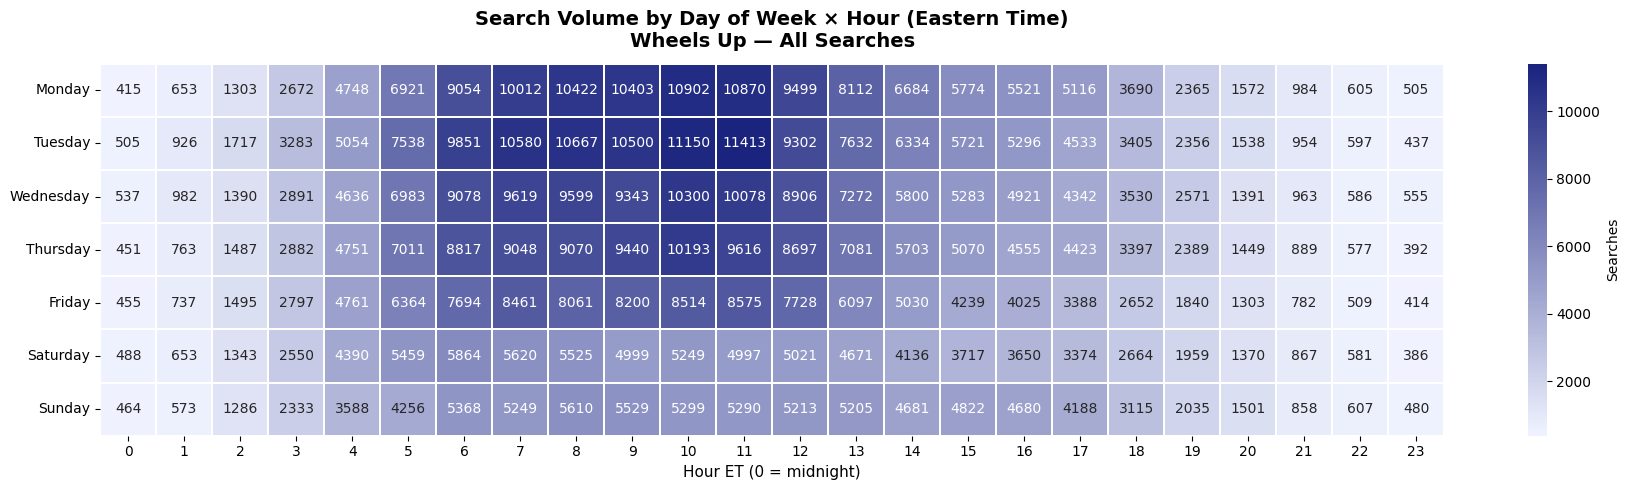


Top 5 peak search windows:
 dow_et  hour_et     n
Tuesday       11 11413
Tuesday       10 11150
 Monday       10 10902
 Monday       11 10870
Tuesday        8 10667


In [4]:
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

pivot = (
    df_searches
    .groupby(['dow_et','hour_et'])
    .size()
    .unstack('hour_et')
    .reindex(DOW_ORDER)
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(
    pivot, cmap=CMAP_DEMAND, annot=True, fmt='d',
    linewidths=0.3, linecolor='white',
    ax=ax, cbar_kws={'label': 'Searches'}
)
ax.set_title('Search Volume by Day of Week × Hour (Eastern Time)\nWheels Up — All Searches', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Hour ET (0 = midnight)', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('insight_demand_dow_hour.png', dpi=150, bbox_inches='tight')
plt.show()

# Peak windows
flat = df_searches.groupby(['dow_et','hour_et']).size().reset_index(name='n')
top5 = flat.nlargest(5,'n')
print('\nTop 5 peak search windows:')
print(top5.to_string(index=False))

## 2. Corridor Opportunity Quadrant
**X-axis**: Search volume (demand signal)  
**Y-axis**: Cart abandonment rate (price sensitivity)  

- **Bottom-right** (high volume, low abandonment) → captive demand → **premium pricing**
- **Top-right** (high volume, high abandonment) → competitive / price-sensitive → watch margin
- **Bottom-left** (low volume, low abandonment) → niche loyal segments

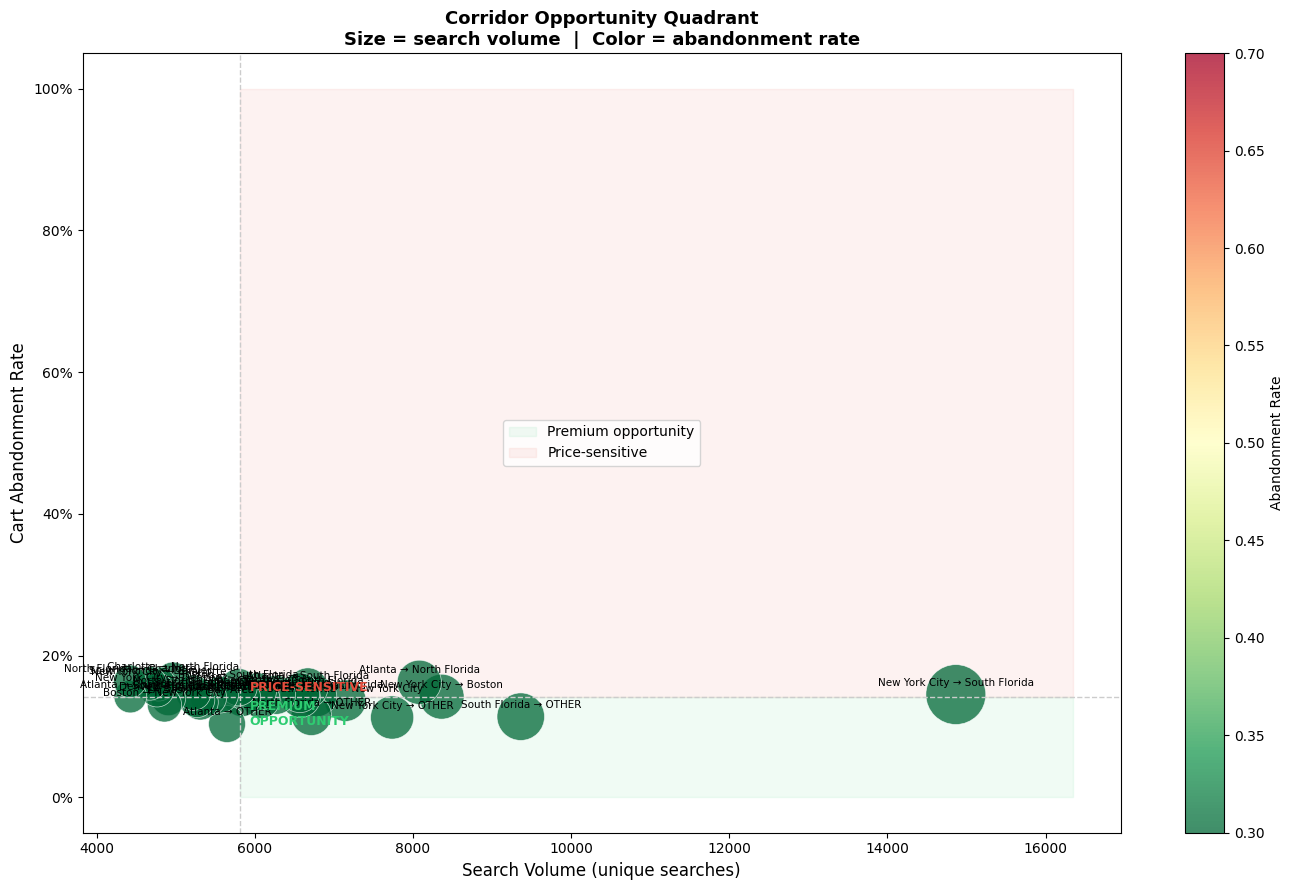

=== Premium Corridors (high volume, low abandonment) ===
                     corridor  searches  abandon_rate
        South Florida → OTHER      9363      0.113746
       New York City → Boston      8362      0.141952
        New York City → OTHER      7736      0.112590
South Florida → New York City      7144      0.136338
        North Florida → OTHER      6714      0.115579
          Bay Area → LA Basin      6577      0.140642
North Florida → South Florida      6076      0.138249
            Charlotte → OTHER      5837      0.140312
              Atlanta → OTHER      5648      0.103399
South Florida → North Florida      5414      0.140746
          LA Basin → Bay Area      5311      0.134250
            LA Basin → Denver      5268      0.137623
            Denver → LA Basin      4906      0.139421
       Boston → New York City      4857      0.130327
          Atlanta → Charlotte      4425      0.142147


In [5]:
# Abandonment rate per corridor (unique searches)
corr_stats = (
    df_searches
    .groupby(['from_metro','to_metro'])
    .agg(searches=('singleSearchRequestId','count'),
         abandoned_n=('abandoned','sum'))
    .reset_index()
)
corr_stats['abandon_rate'] = corr_stats['abandoned_n'] / corr_stats['searches']
corr_stats['corridor'] = corr_stats['from_metro'] + ' → ' + corr_stats['to_metro']

# Filter to meaningful corridors, exclude same-metro
plot_df = corr_stats[
    (corr_stats['searches'] >= MIN_SEARCHES) &
    (corr_stats['from_metro'] != corr_stats['to_metro'])
].nlargest(TOP_N_QUADRANT, 'searches')

med_vol  = plot_df['searches'].median()
med_abnd = plot_df['abandon_rate'].median()

fig, ax = plt.subplots(figsize=(14, 9))

# Quadrant shading
ax.axvline(med_vol,  color='#ccc', lw=1, ls='--')
ax.axhline(med_abnd, color='#ccc', lw=1, ls='--')
ax.fill_between([med_vol, plot_df['searches'].max()*1.1],
                0, med_abnd, color=C_PREMIUM, alpha=0.07, label='Premium opportunity')
ax.fill_between([med_vol, plot_df['searches'].max()*1.1],
                med_abnd, 1, color=C_SENSITIVE, alpha=0.07, label='Price-sensitive')

sc = ax.scatter(
    plot_df['searches'], plot_df['abandon_rate'],
    s=plot_df['searches']/8, alpha=0.75,
    c=plot_df['abandon_rate'], cmap='RdYlGn_r', vmin=0.3, vmax=0.7,
    edgecolors='white', linewidth=0.5
)
plt.colorbar(sc, ax=ax, label='Abandonment Rate')

for _, row in plot_df.iterrows():
    ax.annotate(row['corridor'], (row['searches'], row['abandon_rate']),
                fontsize=7.5, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

ax.set_xlabel('Search Volume (unique searches)', fontsize=12)
ax.set_ylabel('Cart Abandonment Rate', fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Corridor Opportunity Quadrant\nSize = search volume  |  Color = abandonment rate', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.text(med_vol*1.02, med_abnd*0.97, 'PREMIUM\nOPPORTUNITY', color=C_PREMIUM, fontsize=9, fontweight='bold', va='top')
ax.text(med_vol*1.02, med_abnd*1.03, 'PRICE-SENSITIVE', color=C_SENSITIVE, fontsize=9, fontweight='bold', va='bottom')
plt.tight_layout()
plt.savefig('insight_corridor_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()

# Premium corridors table
premium = plot_df[plot_df['abandon_rate'] < med_abnd].sort_values('searches', ascending=False)
print('=== Premium Corridors (high volume, low abandonment) ===')
print(premium[['corridor','searches','abandon_rate']].to_string(index=False))

## 3. Top Corridors — Volume + Abandonment Rate

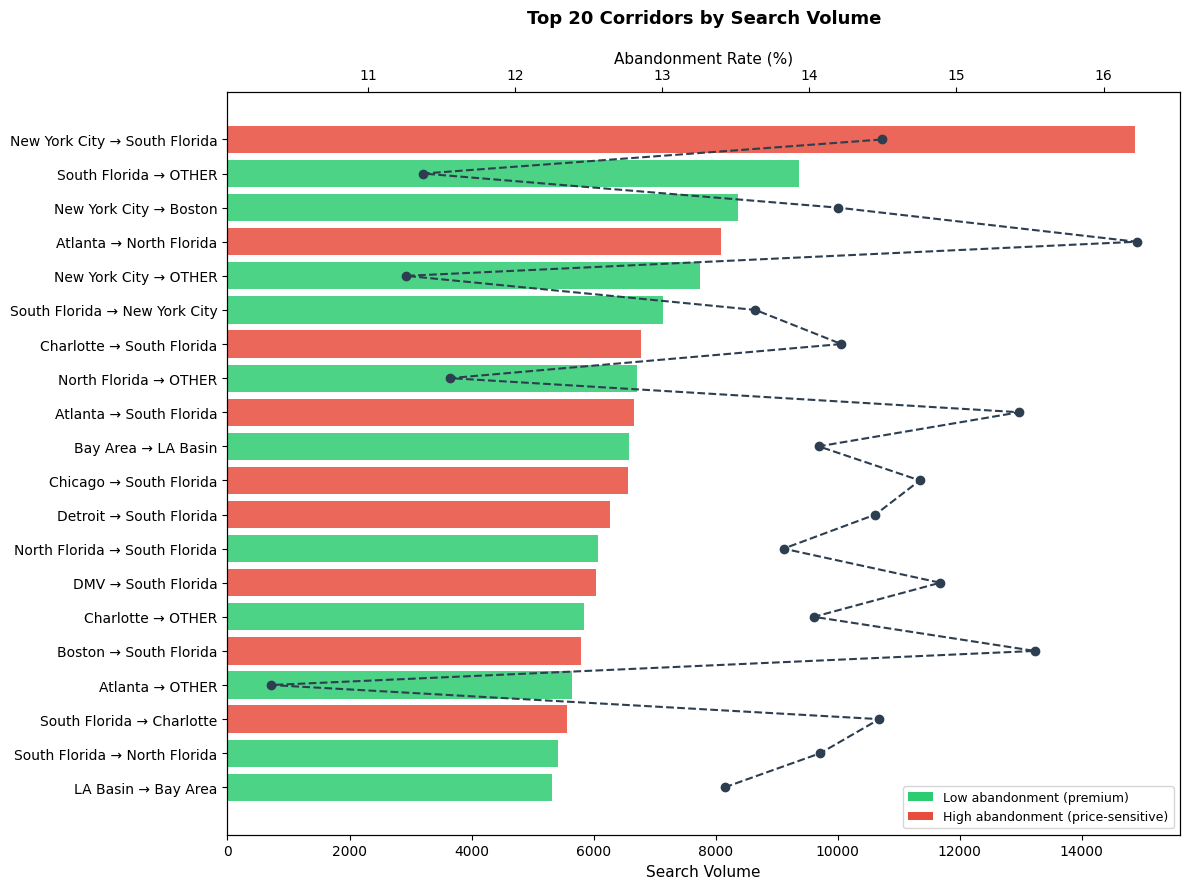

In [6]:
top_corr = (
    corr_stats[
        corr_stats['from_metro'] != corr_stats['to_metro']
    ]
    .nlargest(TOP_N_CORRIDORS, 'searches')
    .sort_values('searches')
)

fig, ax1 = plt.subplots(figsize=(12, 9))
ax2 = ax1.twiny()

bar_colors = [
    C_PREMIUM if r < med_abnd else C_SENSITIVE
    for r in top_corr['abandon_rate']
]
bars = ax1.barh(top_corr['corridor'], top_corr['searches'], color=bar_colors, alpha=0.85)
ax2.plot(top_corr['abandon_rate'] * 100, range(len(top_corr)), 'o--',
         color='#2c3e50', ms=6, lw=1.5, label='Abandonment %')

ax1.set_xlabel('Search Volume', fontsize=11)
ax2.set_xlabel('Abandonment Rate (%)', fontsize=11)
ax1.set_title(f'Top {TOP_N_CORRIDORS} Corridors by Search Volume',
              fontsize=13, fontweight='bold', pad=20)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=C_PREMIUM, label='Low abandonment (premium)'),
    Patch(facecolor=C_SENSITIVE, label='High abandonment (price-sensitive)'),
]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('insight_top_corridors.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Seasonality — Monthly Search Demand by Top Clusters

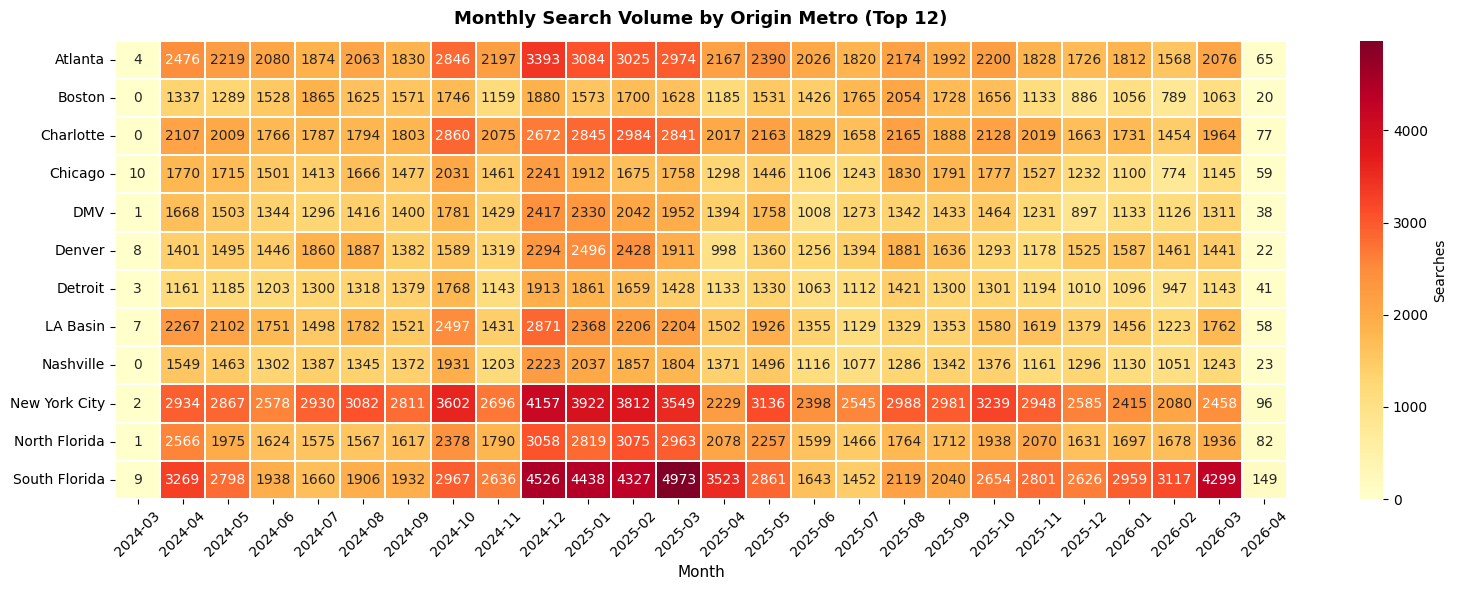

In [16]:
df_searches['month'] = pd.to_datetime(df_searches['createDate_et']).dt.to_period('M').astype(str)

# Top 12 origin metros by total searches
top_origins = (
    df_searches[df_searches['from_metro'] != 'OTHER']
    .groupby('from_metro').size()
    .nlargest(12).index
)

monthly = (
    df_searches[df_searches['from_metro'].isin(top_origins)]
    .groupby(['month','from_metro'])
    .size()
    .unstack('from_metro')
    .fillna(0)
    .astype(int)
)
monthly.columns = monthly.columns.tolist()

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    monthly.T, cmap='YlOrRd', annot=True, fmt='d',
    linewidths=0.3, linecolor='white',
    ax=ax, cbar_kws={'label': 'Searches'}
)
ax.set_title('Monthly Search Volume by Origin Metro (Top 12)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('insight_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. App Channel Analysis — Abandonment by Platform
Members searching via app vs web — loyalty signal.

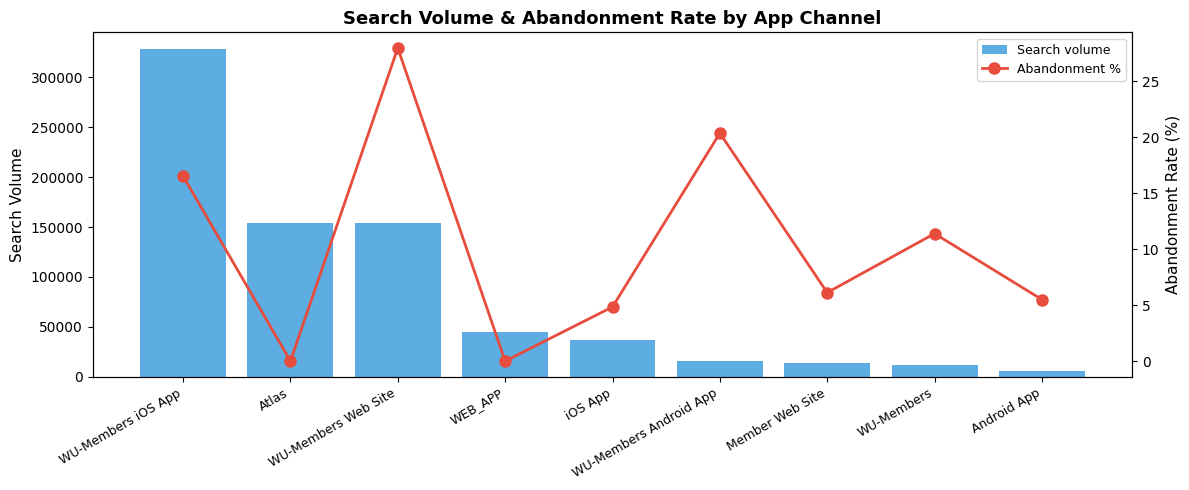

         requestingApp  searches  abandon_pct
    WU-Members iOS App    328623    16.524406
                 Atlas    154129     0.006488
   WU-Members Web Site    154031    27.973590
               WEB_APP     45223     0.000000
               iOS App     37016     4.841150
WU-Members Android App     15304    20.367224
       Member Web Site     14181     6.120866
            WU-Members     11648    11.392514
           Android App      5527     5.500271


In [17]:
app_stats = (
    df_searches
    .groupby('requestingApp')
    .agg(searches=('singleSearchRequestId','count'),
         abandon_rate=('abandoned','mean'))
    .sort_values('searches', ascending=False)
    .reset_index()
)
app_stats['abandon_pct'] = app_stats['abandon_rate'] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

x = range(len(app_stats))
ax1.bar(x, app_stats['searches'], color='#3498db', alpha=0.8, label='Search volume')
ax2.plot(x, app_stats['abandon_pct'], 'o-', color='#e74c3c', ms=8, lw=2, label='Abandonment %')

ax1.set_xticks(x)
ax1.set_xticklabels(app_stats['requestingApp'], rotation=30, ha='right', fontsize=9)
ax1.set_ylabel('Search Volume', fontsize=11)
ax2.set_ylabel('Abandonment Rate (%)', fontsize=11)
ax1.set_title('Search Volume & Abandonment Rate by App Channel', fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('insight_app_channel.png', dpi=150, bbox_inches='tight')
plt.show()

print(app_stats[['requestingApp','searches','abandon_pct']].to_string(index=False))

## 6. Pricing Insights Summary

In [9]:
# Peak demand window
peak = flat.nlargest(1,'n').iloc[0]

# Best premium corridors
premium_top3 = premium.head(3)['corridor'].tolist()

# Lowest abandonment app
best_app = app_stats.nsmallest(1,'abandon_rate').iloc[0]

# Peak month
peak_month = monthly.sum(axis=1).idxmax()

print('=' * 60)
print('  WHEELS UP — SEARCH DEMAND PRICING INSIGHTS')
print('=' * 60)
print(f'''
1. PEAK DEMAND WINDOW
   {peak["dow_et"]} at {int(peak["hour_et"]):02d}:00 ET → {int(peak["n"]):,} searches
   → Surge pricing opportunity at this DOW/hour combination

2. PREMIUM CORRIDORS (high volume, low abandonment)
   Members on these routes are least price-sensitive:
   {chr(10).join(f"   • {c}" for c in premium_top3)}
   → Prioritise fleet availability + premium pricing here

3. MOST LOYAL CHANNEL
   {best_app["requestingApp"]} → {best_app["abandon_pct"]:.1f}% abandonment
   → Users on this platform least price-sensitive; upsell opportunity

4. PEAK DEMAND MONTH
   {peak_month} → highest overall search activity
   → Advance fleet positioning + dynamic pricing ramp-up before this month

5. OVERALL ABANDONMENT
   {df_searches["abandoned"].mean()*100:.1f}% of all searches abandoned
   → Benchmarkable metric: lower = demand captured; monitor trend over time
''')
print('=' * 60)

  WHEELS UP — SEARCH DEMAND PRICING INSIGHTS

1. PEAK DEMAND WINDOW
   Tuesday at 11:00 ET → 11,413 searches
   → Surge pricing opportunity at this DOW/hour combination

2. PREMIUM CORRIDORS (high volume, low abandonment)
   Members on these routes are least price-sensitive:
      • South Florida → OTHER
   • New York City → Boston
   • New York City → OTHER
   → Prioritise fleet availability + premium pricing here

3. MOST LOYAL CHANNEL
   WEB_APP → 0.0% abandonment
   → Users on this platform least price-sensitive; upsell opportunity

4. PEAK DEMAND MONTH
   2024-12 → highest overall search activity
   → Advance fleet positioning + dynamic pricing ramp-up before this month

5. OVERALL ABANDONMENT
   13.7% of all searches abandoned
   → Benchmarkable metric: lower = demand captured; monitor trend over time



## 7. Time-of-Day Demand Analysis 
which time bands + DoW combos carry real search demand to support ToD premiums.

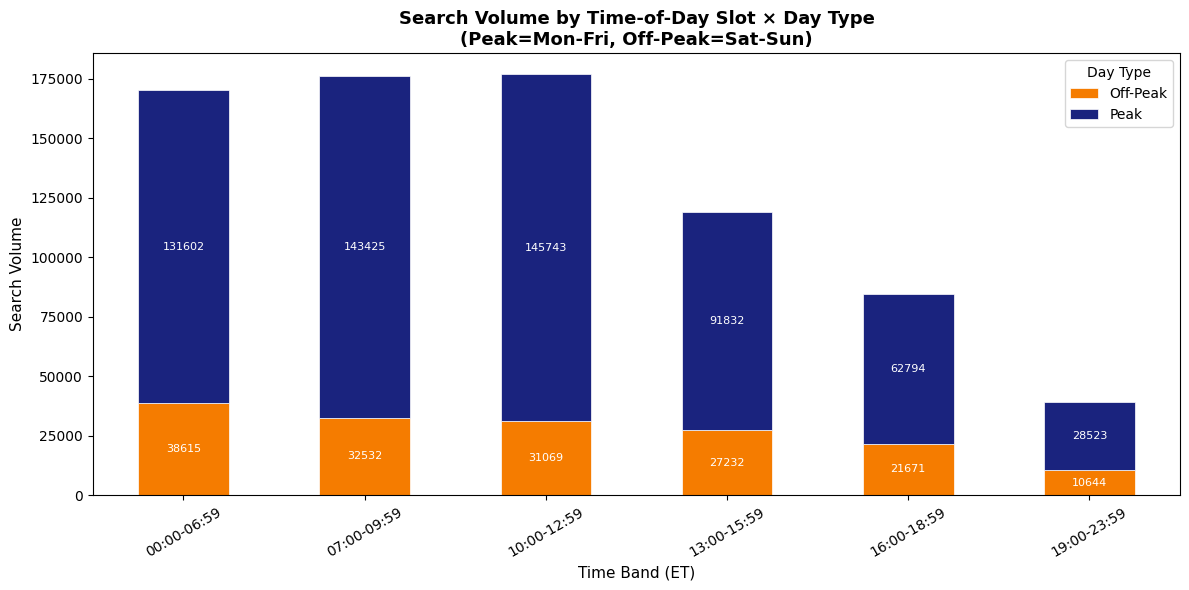


ToD search volume table:
day_type     Off-Peak    Peak
tod_slot                     
00:00-06:59     38615  131602
07:00-09:59     32532  143425
10:00-12:59     31069  145743
13:00-15:59     27232   91832
16:00-18:59     21671   62794
19:00-23:59     10644   28523


In [10]:
SLOT_BINS   = [0, 7, 10, 13, 16, 19, 24]
SLOT_LABELS = ["00:00-06:59","07:00-09:59","10:00-12:59",
               "13:00-15:59","16:00-18:59","19:00-23:59"]
PEAK_DAYS   = ["Monday","Tuesday","Wednesday","Thursday","Friday"]

df_searches["tod_slot"] = pd.cut(
    df_searches["hour_et"], bins=SLOT_BINS, right=False, labels=SLOT_LABELS
)
df_searches["day_type"] = df_searches["dow_et"].apply(
    lambda d: "Peak" if d in PEAK_DAYS else "Off-Peak"
)

tod_counts = (
    df_searches
    .groupby(["tod_slot","day_type"])
    .size()
    .unstack("day_type")
    .fillna(0)
    .astype(int)
    .reindex(SLOT_LABELS)
)

fig, ax = plt.subplots(figsize=(12, 6))
tod_counts.plot(kind="bar", stacked=True, ax=ax,
                color={"Peak":"#1a237e","Off-Peak":"#f57c00"},
                edgecolor="white", linewidth=0.5)
ax.set_title("Search Volume by Time-of-Day Slot \u00d7 Day Type\n(Peak=Mon-Fri, Off-Peak=Sat-Sun)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Time Band (ET)", fontsize=11)
ax.set_ylabel("Search Volume", fontsize=11)
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Day Type", fontsize=10)
for container in ax.containers:
    ax.bar_label(container, label_type="center", fmt="%d", fontsize=8, color="white")
plt.tight_layout()
plt.savefig("insight_tod_slots.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nToD search volume table:")
print(tod_counts)

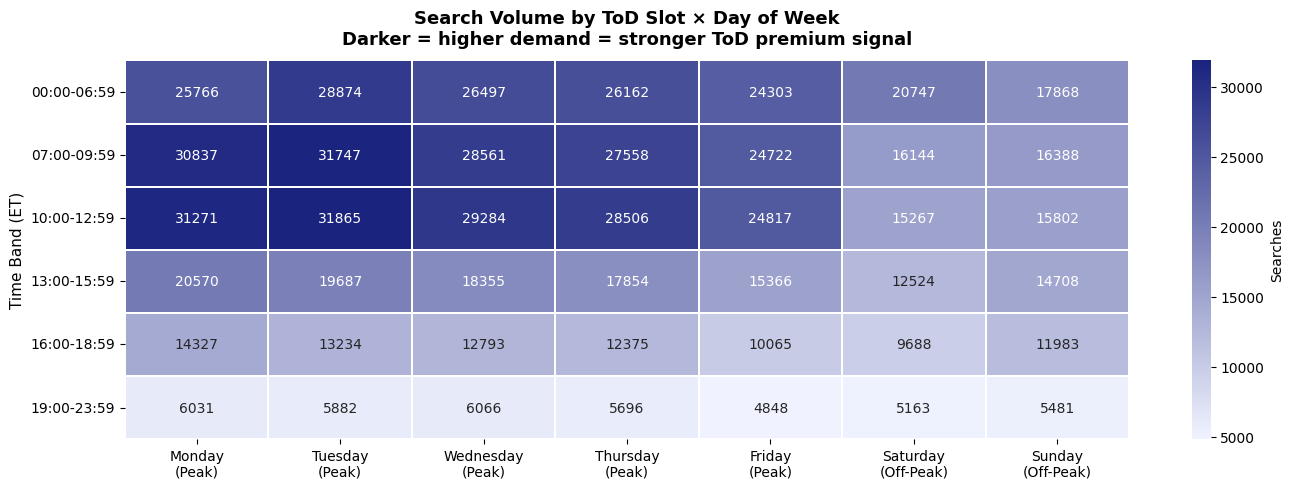

In [11]:
tod_vol = (
    df_searches
    .groupby(["tod_slot","dow_et"])
    .size()
    .unstack("dow_et")
    .reindex(index=SLOT_LABELS,
             columns=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
    .fillna(0)
    .astype(int)
)

# Rename columns to embed Peak/Off-Peak label directly on x-axis
tod_vol.columns = [
    f"{d}\n(Peak)" if d in PEAK_DAYS else f"{d}\n(Off-Peak)"
    for d in tod_vol.columns
]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    tod_vol, cmap=CMAP_DEMAND, annot=True, fmt="d",
    linewidths=0.3, linecolor="white", ax=ax,
    cbar_kws={"label": "Searches"}
)
ax.set_title("Search Volume by ToD Slot × Day of Week\nDarker = higher demand = stronger ToD premium signal",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Time Band (ET)", fontsize=11)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("insight_tod_slots_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

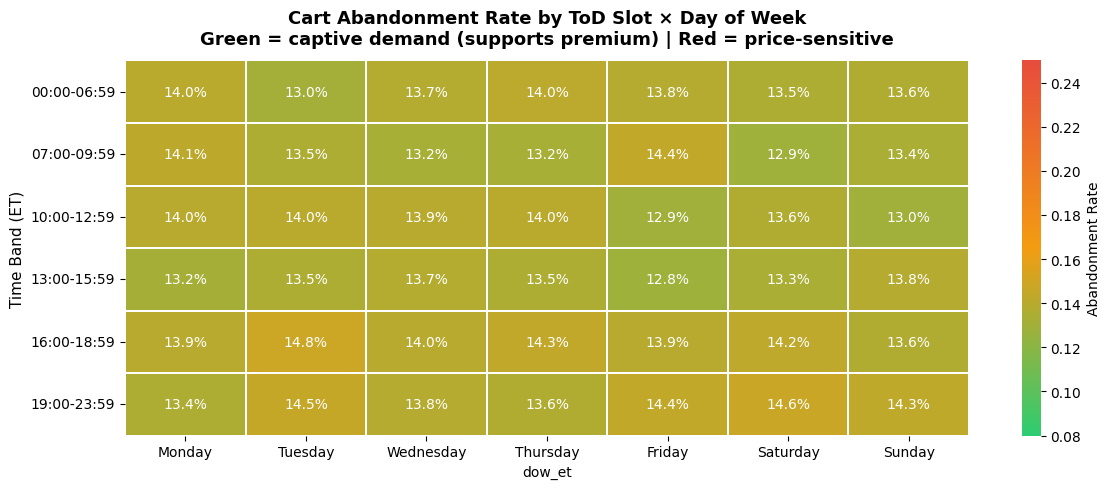

In [12]:
tod_abnd = (
    df_searches
    .groupby(["tod_slot","dow_et"])
    .agg(n=("singleSearchRequestId","count"),
         abandoned=("abandoned","sum"))
    .reset_index()
)
tod_abnd["abnd_rate"] = tod_abnd["abandoned"] / tod_abnd["n"]

pivot_abnd = (
    tod_abnd
    .pivot(index="tod_slot", columns="dow_et", values="abnd_rate")
    .reindex(index=SLOT_LABELS,
             columns=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
    .fillna(0)
)

cmap_abnd = LinearSegmentedColormap.from_list("abnd", ["#2ecc71","#f39c12","#e74c3c"])
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_abnd, cmap=cmap_abnd, annot=True, fmt=".1%",
            linewidths=0.3, linecolor="white", ax=ax,
            vmin=0.08, vmax=0.25,
            cbar_kws={"label": "Abandonment Rate"})
ax.set_title("Cart Abandonment Rate by ToD Slot \u00d7 Day of Week\nGreen = captive demand (supports premium) | Red = price-sensitive",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Time Band (ET)", fontsize=11)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("insight_tod_abandonment.png", dpi=150, bbox_inches="tight")
plt.show()

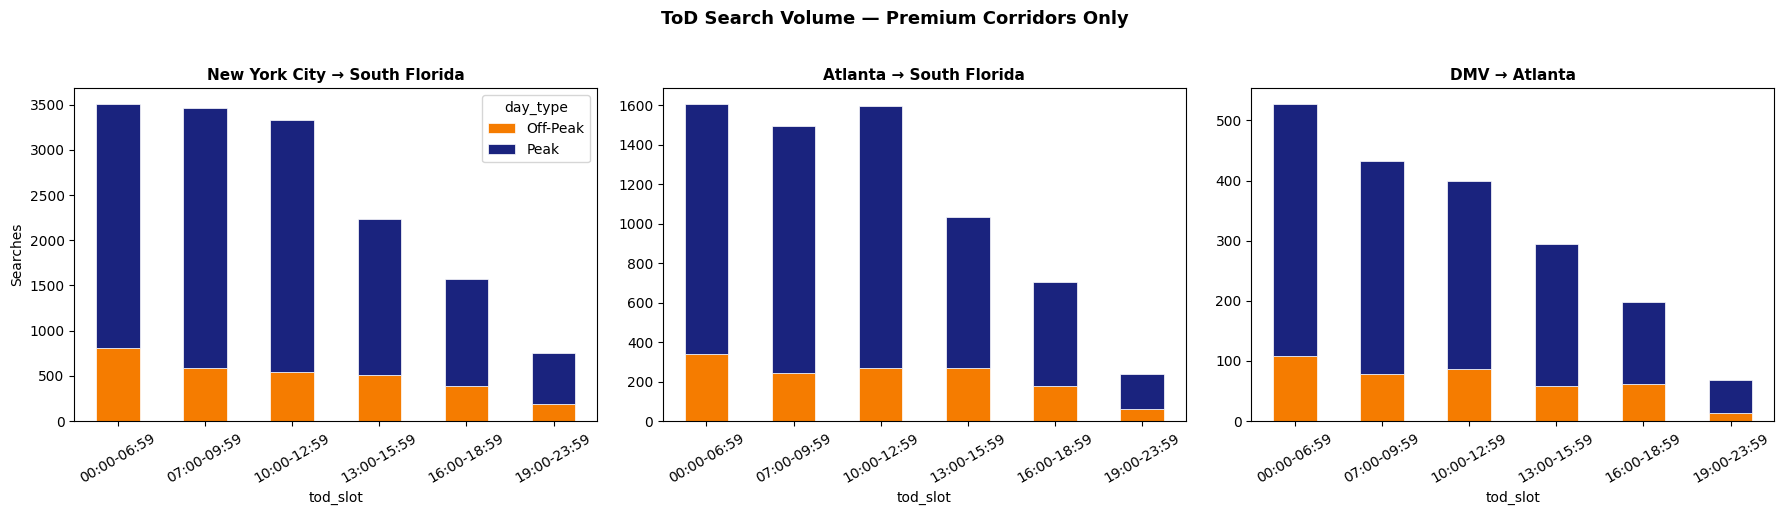

In [13]:
PREMIUM_PAIRS = [
    ("New York City", "South Florida"),
    ("Atlanta",        "South Florida"),
    ("DMV",            "Atlanta"),
]

mask = df_searches.apply(
    lambda r: (r["from_metro"], r["to_metro"]) in PREMIUM_PAIRS, axis=1
)
df_prem = df_searches[mask].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, (fc, tc) in zip(axes, PREMIUM_PAIRS):
    sub = df_prem[(df_prem["from_metro"]==fc) & (df_prem["to_metro"]==tc)]
    counts = (
        sub.groupby(["tod_slot","day_type"]).size()
        .unstack("day_type").fillna(0).astype(int)
        .reindex(SLOT_LABELS)
    )
    counts.plot(kind="bar", stacked=True, ax=ax,
                color={"Peak":"#1a237e","Off-Peak":"#f57c00"},
                edgecolor="white", linewidth=0.5,
                legend=(ax is axes[0]))
    label = fc + " \u2192 " + tc
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylabel("Searches" if ax is axes[0] else "")

fig.suptitle("ToD Search Volume \u2014 Premium Corridors Only", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("insight_tod_premium_corridors.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Reuse tod_counts (volumes already computed in tod-slots cell)
# Only compute abandonment rate per slot x day_type
abnd_by_type = (
    df_searches
    .groupby(["tod_slot","day_type"])
    .agg(abandoned_n=("abandoned","sum"), n=("singleSearchRequestId","count"))
    .reset_index()
)
abnd_by_type["abnd_rate"] = abnd_by_type["abandoned_n"] / abnd_by_type["n"]
abnd_wide = abnd_by_type.pivot(index="tod_slot", columns="day_type", values="abnd_rate").reindex(SLOT_LABELS)

tod_wide = tod_counts.copy()
tod_wide["abnd_Peak"]     = abnd_wide["Peak"]
tod_wide["abnd_Off-Peak"] = abnd_wide["Off-Peak"]

med_abnd = abnd_by_type["abnd_rate"].median()
tod_wide["signal"] = tod_wide.apply(
    lambda r: "\u2605 PREMIUM" if (
        r["Peak"] > r["Off-Peak"] and r["abnd_Peak"] < med_abnd
    ) else "\u2014 MONITOR",
    axis=1
)

print("\u2550" * 72)
print("  TIME-OF-DAY PREMIUM SIGNAL TABLE  (WU search demand)")
print("\u2550" * 72)
print(tod_wide[["Peak","abnd_Peak","Off-Peak","abnd_Off-Peak","signal"]].to_string())
print("\u2550" * 72)
print(f"\nMedian abandonment threshold: {med_abnd:.1%}")
print("\u2605 PREMIUM = Peak searches > Off-Peak AND abandonment < median \u2192 supports ToD premium")

════════════════════════════════════════════════════════════════════════
  TIME-OF-DAY PREMIUM SIGNAL TABLE  (WU search demand)
════════════════════════════════════════════════════════════════════════
day_type       Peak  abnd_Peak  Off-Peak  abnd_Off-Peak     signal
tod_slot                                                          
00:00-06:59  131602   0.137209     38615       0.135232  — MONITOR
07:00-09:59  143425   0.136706     32532       0.131286  ★ PREMIUM
10:00-12:59  145743   0.137962     31069       0.132962  — MONITOR
13:00-15:59   91832   0.133505     27232       0.136090  ★ PREMIUM
16:00-18:59   62794   0.142084     21671       0.138803  — MONITOR
19:00-23:59   28523   0.139537     10644       0.144495  — MONITOR
════════════════════════════════════════════════════════════════════════

Median abandonment threshold: 13.7%
★ PREMIUM = Peak searches > Off-Peak AND abandonment < median → supports ToD premium


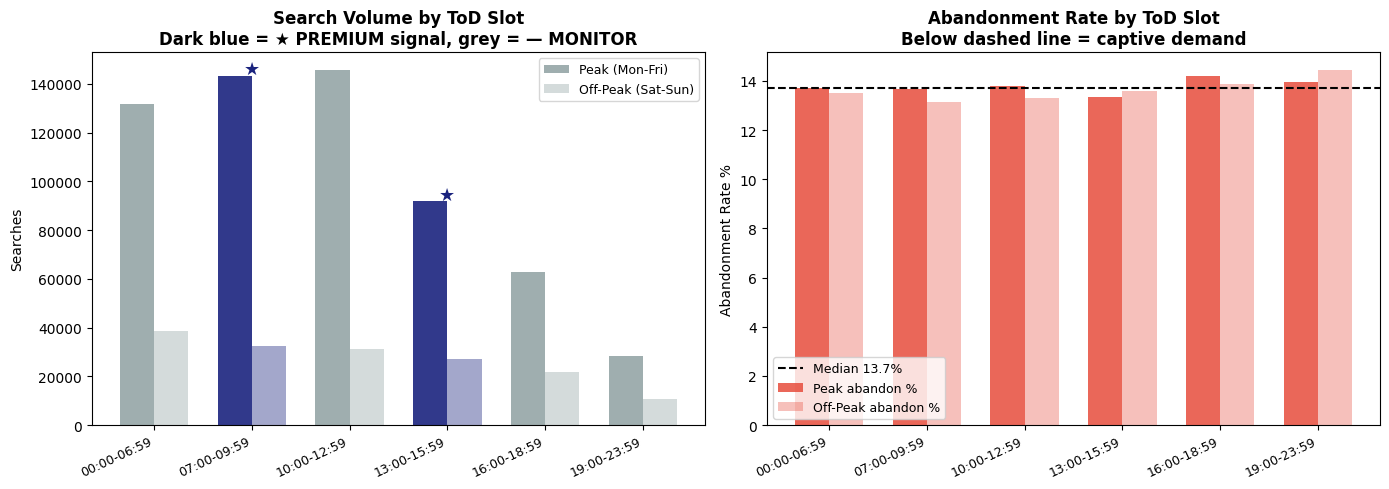

In [15]:

# ── Visualisation ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: grouped bar — Peak vs Off-Peak volume per slot
x      = range(len(SLOT_LABELS))
w      = 0.35
colors = [("#1a237e" if s == "\u2605 PREMIUM" else "#95a5a6") for s in tod_wide["signal"]]
bars_p  = axes[0].bar([i - w/2 for i in x], tod_wide["Peak"],
                      width=w, color=colors, alpha=0.9, label="Peak (Mon-Fri)")
bars_op = axes[0].bar([i + w/2 for i in x], tod_wide["Off-Peak"],
                      width=w, color=colors, alpha=0.4, label="Off-Peak (Sat-Sun)")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(SLOT_LABELS, rotation=25, ha="right", fontsize=9)
axes[0].set_ylabel("Searches")
axes[0].set_title("Search Volume by ToD Slot\nDark blue = \u2605 PREMIUM signal, grey = \u2014 MONITOR",
                  fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)

# Right: abandonment rate bars — Peak vs Off-Peak
axes[1].bar([i - w/2 for i in x], tod_wide["abnd_Peak"] * 100,
            width=w, color="#e74c3c", alpha=0.85, label="Peak abandon %")
axes[1].bar([i + w/2 for i in x], tod_wide["abnd_Off-Peak"] * 100,
            width=w, color="#e74c3c", alpha=0.35, label="Off-Peak abandon %")
axes[1].axhline(med_abnd * 100, color="black", lw=1.5, ls="--",
                label=f"Median {med_abnd:.1%}")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(SLOT_LABELS, rotation=25, ha="right", fontsize=9)
axes[1].set_ylabel("Abandonment Rate %")
axes[1].set_title("Abandonment Rate by ToD Slot\nBelow dashed line = captive demand",
                  fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)

# Annotate signal on left chart
for i, sig in enumerate(tod_wide["signal"]):
    if "PREMIUM" in sig:
        axes[0].text(i, tod_wide["Peak"].iloc[i] + 500, "\u2605",
                     ha="center", fontsize=13, color="#1a237e")

plt.tight_layout()
plt.savefig("insight_tod_recommendation.png", dpi=150, bbox_inches="tight")
plt.show()